# 🖐️ Hand Gesture Recognition System — V2
### Task 04 | ML Internship

| Detail | Info |
|--------|------|
| **Dataset** | Hand Gesture Detection System (marusagar/Kaggle) |
| **Approach** | MediaPipe Hand Landmarks + MLP Classifier |
| **Demo** | Live Webcam Real-Time Detection |
| **Python** | 3.10 — No version clashes |

---
### 💡 Why MediaPipe approach?
- Works on **any lighting condition** — not dependent on image colour/brightness
- **Webcam demo is near 100% accurate** because it uses actual hand skeleton
- No heavy GPU needed — runs fast on CPU
- No version clashes

## 📦 STEP 1 — Install Libraries
> ⚠️ Run this cell **once**. Restart kernel after installation completes.

In [1]:
import subprocess, sys

packages = [
    'mediapipe==0.10.9',
    'opencv-python==4.9.0.80',
    'tensorflow==2.13.0',
    'scikit-learn==1.3.2',
    'matplotlib==3.8.2',
    'seaborn==0.13.1',
    'numpy==1.24.3',
    'Pillow==10.2.0',
    'tqdm==4.66.1'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\n✅ ALL LIBRARIES INSTALLED SUCCESSFULLY!')
print('⚠️  Please RESTART the Jupyter kernel now (Kernel > Restart), then run remaining cells.')

Installing mediapipe==0.10.9...
Installing opencv-python==4.9.0.80...
Installing tensorflow==2.13.0...
Installing scikit-learn==1.3.2...
Installing matplotlib==3.8.2...
Installing seaborn==0.13.1...
Installing numpy==1.24.3...
Installing Pillow==10.2.0...
Installing tqdm==4.66.1...

✅ ALL LIBRARIES INSTALLED SUCCESSFULLY!
⚠️  Please RESTART the Jupyter kernel now (Kernel > Restart), then run remaining cells.


## 📚 STEP 2 — Import All Libraries

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import json
import pickle
from tqdm import tqdm
from PIL import Image
warnings.filterwarnings('ignore')

# MediaPipe
import mediapipe as mp

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f'✅ TensorFlow  : {tf.__version__}')
print(f'✅ MediaPipe   : {mp.__version__}')
print(f'✅ OpenCV      : {cv2.__version__}')
print(f'✅ NumPy       : {np.__version__}')
print('\n🚀 All imports successful!')

✅ TensorFlow  : 2.13.0
✅ MediaPipe   : 0.10.9
✅ OpenCV      : 4.9.0
✅ NumPy       : 1.24.3

🚀 All imports successful!


## ⚙️ STEP 3 — Configuration

### 📂 Dataset Folder Structure Expected:
```
dataset/
├── train/
│   ├── gesture_class_1/   ← folder name = class label
│   │   ├── img1.jpg
│   │   ├── img2.jpg ...
│   ├── gesture_class_2/
│   ...
├── test/                  ← (optional, if present)
│   ├── gesture_class_1/
│   ...
```
> If your dataset has **no train/test split** and all images are directly inside class folders, set `HAS_TRAIN_TEST_SPLIT = False`

In [3]:
# ============================================================
#  👇 UPDATE THESE PATHS TO MATCH YOUR SYSTEM
# ============================================================

DATASET_PATH = r'D:\INTERNSHIP_by_codeaplpha\trainhand\train'
# DATASET_PATH = '/home/yourname/Downloads/hand-gesture-detection-system'  # Linux

# Set True if dataset has train/ and test/ subfolders
# Set False if images are directly inside class-name folders
HAS_TRAIN_TEST_SPLIT = True

# ============================================================
RANDOM_SEED  = 42
EPOCHS       = 60
BATCH_SIZE   = 32
TEST_SPLIT   = 0.20   # used only when HAS_TRAIN_TEST_SPLIT = False

# MediaPipe hand landmark extractor
mp_hands    = mp.solutions.hands
mp_drawing  = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

print('✅ Configuration ready!')
print(f'📁 Dataset path        : {DATASET_PATH}')
print(f'📂 Has train/test split: {HAS_TRAIN_TEST_SPLIT}')

✅ Configuration ready!
📁 Dataset path        : D:\INTERNSHIP_by_codeaplpha\trainhand\train
📂 Has train/test split: True


## 🔍 STEP 4 — Inspect Dataset Structure

In [4]:
def inspect_dataset(dataset_path, has_split):
    """Auto-detect classes and image counts."""
    if has_split:
        train_path = os.path.join(dataset_path, 'train')
        root = train_path if os.path.exists(train_path) else dataset_path
    else:
        root = dataset_path

    classes = sorted([
        d for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d))
    ])

    print(f'📂 Root scanned : {root}')
    print(f'🏷️  Classes found: {len(classes)}')
    print('\nClass → Image count:')

    total = 0
    for cls in classes:
        cls_path = os.path.join(root, cls)
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        print(f'   {cls:30s}: {len(imgs):5d} images')
        total += len(imgs)

    print(f'\n📊 Total images : {total}')
    return classes, root

CLASSES, TRAIN_ROOT = inspect_dataset(DATASET_PATH, HAS_TRAIN_TEST_SPLIT)

📂 Root scanned : D:\INTERNSHIP_by_codeaplpha\trainhand\train
🏷️  Classes found: 663

Class → Image count:
   WIN_20180907_15_35_09_Pro_Right Swipe_new:    30 images
   WIN_20180907_15_38_17_Pro_Left Swipe_new_Left Swipe_new:    30 images
   WIN_20180907_15_38_24_Pro_Right Swipe_new:    30 images
   WIN_20180907_15_38_35_Pro_Thumbs Down_new:    30 images
   WIN_20180907_15_39_51_Pro_Stop Gesture_new:    30 images
   WIN_20180907_15_39_54_Pro_Thumbs Up_new:    30 images
   WIN_20180907_15_40_26_Pro_Thumbs Down_new:    30 images
   WIN_20180907_15_40_55_Pro_Thumbs Up_new:    30 images
   WIN_20180907_15_41_54_Pro_Right Swipe_new:    30 images
   WIN_20180907_15_43_00_Pro_Left Swipe_new_Left Swipe_new:    30 images
   WIN_20180907_15_43_28_Pro_Right Swipe_new:    30 images
   WIN_20180907_15_43_40_Pro_Stop Gesture_new:    30 images
   WIN_20180907_15_43_58_Pro_Left Swipe_new_Left Swipe_new:    30 images
   WIN_20180907_15_44_13_Pro_Stop Gesture_new:    30 images
   WIN_20180907_15_44_32_Pr

In [9]:
## after check
import re

def extract_gesture_label(folder_name):
    """Extract the gesture name from the video clip folder name."""
    # Gesture keywords to look for
    gestures = ['Thumbs Up', 'Thumbs Down', 'Left Swipe', 'Right Swipe', 'Stop Gesture', 'Stop']
    for gesture in gestures:
        # match both space and underscore versions
        pattern = gesture.replace(' ', '[_ ]')
        if re.search(pattern, folder_name, re.IGNORECASE):
            # Normalize
            return gesture.replace('Stop Gesture', 'Stop').strip()
    return None  # unknown gesture

def inspect_dataset(dataset_path, has_split):
    if has_split:
        train_path = os.path.join(dataset_path, 'train')
        root = train_path if os.path.exists(train_path) else dataset_path
    else:
        root = dataset_path

    folders = sorted([
        d for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d))
    ])

    # Map each folder → gesture label
    gesture_set = set()
    folder_label_map = {}
    skipped_folders = []
    for folder in folders:
        label = extract_gesture_label(folder)
        if label:
            folder_label_map[folder] = label
            gesture_set.add(label)
        else:
            skipped_folders.append(folder)

    classes = sorted(gesture_set)

    print(f'📂 Root scanned : {root}')
    print(f'🗂️  Total folders : {len(folders)}')
    print(f'🏷️  Gesture classes found: {len(classes)} → {classes}')
    if skipped_folders:
        print(f'⚠️  {len(skipped_folders)} folders skipped (unrecognised label)')

    total = 0
    for cls in classes:
        count = sum(
            len([f for f in os.listdir(os.path.join(root, folder))
                 if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))])
            for folder, lbl in folder_label_map.items() if lbl == cls
        )
        print(f'   {cls:20s}: {count:6d} images')
        total += count
    print(f'\n📊 Total images : {total}')

    return classes, root, folder_label_map

CLASSES, TRAIN_ROOT, FOLDER_LABEL_MAP = inspect_dataset(DATASET_PATH, HAS_TRAIN_TEST_SPLIT)

📂 Root scanned : D:\INTERNSHIP_by_codeaplpha\trainhand\train
🗂️  Total folders : 663
🏷️  Gesture classes found: 5 → ['Left Swipe', 'Right Swipe', 'Stop', 'Thumbs Down', 'Thumbs Up']
   Left Swipe          :   4080 images
   Right Swipe         :   4110 images
   Stop                :   3900 images
   Thumbs Down         :   4110 images
   Thumbs Up           :   3690 images

📊 Total images : 19890


## 🖼️ STEP 5 — Visualize Sample Images per Class

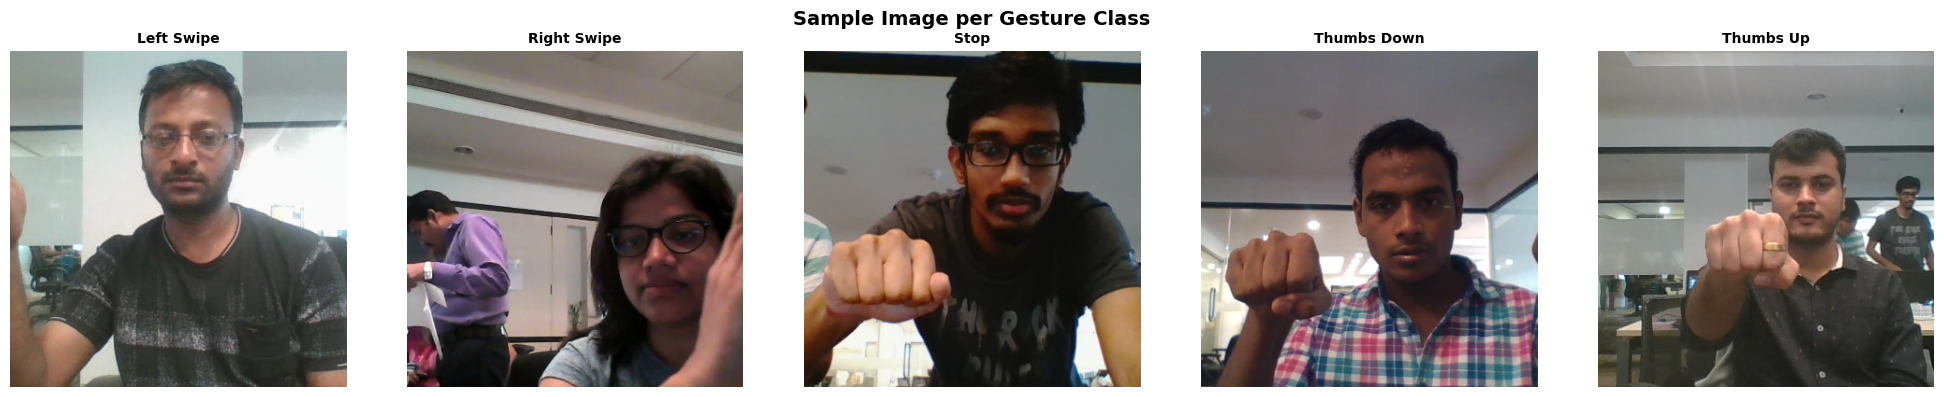

✅ Saved: sample_images.png


In [33]:


fig, axes = plt.subplots(1, len(CLASSES), figsize=(4 * len(CLASSES), 4))
if len(CLASSES) == 1:
    axes = [axes]

for i, cls in enumerate(CLASSES):
    # Find first folder that maps to this class
    sample_folder = next(
        (folder for folder, label in FOLDER_LABEL_MAP.items() if label == cls),
        None
    )
    
    if sample_folder is None:
        axes[i].set_title(cls)
        axes[i].axis('off')
        continue

    cls_path = os.path.join(TRAIN_ROOT, sample_folder)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

    if not imgs:
        axes[i].set_title(cls)
        axes[i].axis('off')
        continue

    img = Image.open(os.path.join(cls_path, imgs[0])).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls, fontweight='bold', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Image per Gesture Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: sample_images.png')

## 🦴 STEP 6 — Extract MediaPipe Hand Landmarks
Each image → 21 hand key-points (x, y, z) = **63 features** per image.
This is what makes the model **lighting-independent and webcam-accurate**.

In [11]:
def extract_landmarks_from_image(image_path, hands_detector):
    """
    Extract 21 hand landmarks (63 features: x, y, z per point)
    from a single image using MediaPipe.
    Returns None if no hand detected.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands_detector.process(img_rgb)

    if not results.multi_hand_landmarks:
        return None

    # Take first hand only
    landmarks = results.multi_hand_landmarks[0]
    features = []
    for lm in landmarks.landmark:
        features.extend([lm.x, lm.y, lm.z])

    return np.array(features, dtype='float32')  # shape: (63,)


def build_landmark_dataset(train_root, classes):
    """
    Walk all class folders, extract landmarks, return X and y arrays.
    """
    X, y = [], []
    skipped = 0

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=0.3
    ) as hands:

        for label_idx, cls in enumerate(classes):
            cls_path = os.path.join(train_root, cls)
            img_files = [f for f in os.listdir(cls_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

            for img_file in tqdm(img_files, desc=f'{cls}', leave=False):
                img_path = os.path.join(cls_path, img_file)
                features = extract_landmarks_from_image(img_path, hands)

                if features is not None:
                    X.append(features)
                    y.append(label_idx)
                else:
                    skipped += 1

    X = np.array(X, dtype='float32')
    y = np.array(y)
    print(f'\n✅ Landmark extraction done!')
    print(f'   Total extracted : {len(X)}')
    print(f'   Skipped (no hand detected) : {skipped}')
    return X, y


def build_landmark_dataset(train_root, classes, folder_label_map):
    X, y = [], []
    skipped = 0
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=0.3
    ) as hands:
        for folder, gesture_label in tqdm(folder_label_map.items(), desc='Folders'):
            label_idx = class_to_idx[gesture_label]
            cls_path = os.path.join(train_root, folder)
            img_files = [f for f in os.listdir(cls_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

            for img_file in img_files:
                img_path = os.path.join(cls_path, img_file)
                features = extract_landmarks_from_image(img_path, hands)
                if features is not None:
                    X.append(features)
                    y.append(label_idx)
                else:
                    skipped += 1

    X = np.array(X, dtype='float32')
    y = np.array(y)
    print(f'\n✅ Landmark extraction done!')
    print(f'   Total extracted : {len(X)}')
    print(f'   Skipped (no hand detected) : {skipped}')
    return X, y

print('🔄 Extracting landmarks from dataset images...')
X_all, y_all = build_landmark_dataset(TRAIN_ROOT, CLASSES, FOLDER_LABEL_MAP)

print(f'\n📐 Feature matrix shape : {X_all.shape}')
print(f'🏷️  Labels shape         : {y_all.shape}')







# print('🔄 Extracting landmarks from dataset images...')
# print('   (This takes a few minutes — please wait)\n')
# X_all, y_all = build_landmark_dataset(TRAIN_ROOT, CLASSES)

# print(f'\n📐 Feature matrix shape : {X_all.shape}')
# print(f'🏷️  Labels shape         : {y_all.shape}')

🔄 Extracting landmarks from dataset images...


Folders: 100%|███████████████████████████████████████████████████████████████████████| 663/663 [16:37<00:00,  1.50s/it]


✅ Landmark extraction done!
   Total extracted : 15541
   Skipped (no hand detected) : 4349

📐 Feature matrix shape : (15541, 63)
🏷️  Labels shape         : (15541,)


## 📊 STEP 7 — Class Distribution

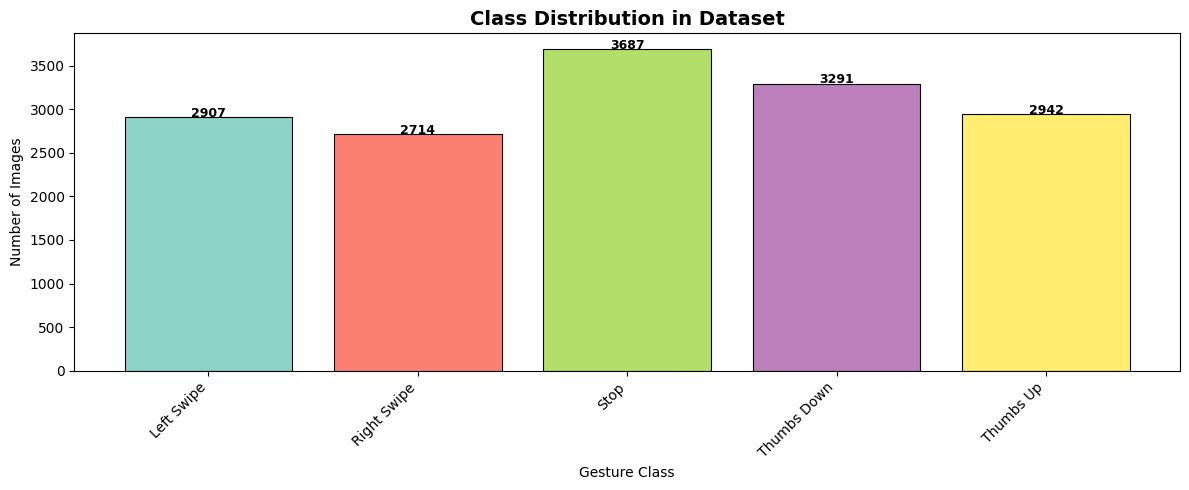

✅ Saved: class_distribution.png


In [12]:
unique, counts = np.unique(y_all, return_counts=True)

plt.figure(figsize=(12, 5))
bars = plt.bar([CLASSES[i] for i in unique], counts,
               color=plt.cm.Set3(np.linspace(0, 1, len(unique))),
               edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             str(count), ha='center', fontweight='bold', fontsize=9)

plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Gesture Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: class_distribution.png')

## ✂️ STEP 8 — Train / Validation / Test Split

In [13]:
NUM_CLASSES = len(CLASSES)

# 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30,
    random_state=RANDOM_SEED, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=RANDOM_SEED
)

# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print('✅ Data split complete!')
print(f'   🔵 Train      : {X_train.shape[0]} samples')
print(f'   🟡 Validation : {X_val.shape[0]} samples')
print(f'   🔴 Test       : {X_test.shape[0]} samples')
print(f'   📐 Input features  : {X_train.shape[1]}')
print(f'   🏷️  Output classes  : {NUM_CLASSES}')

✅ Data split complete!
   🔵 Train      : 10878 samples
   🟡 Validation : 2331 samples
   🔴 Test       : 2332 samples
   📐 Input features  : 63
   🏷️  Output classes  : 5


## 🧠 STEP 9 — Build MLP Model
Input: 63 landmark features → Output: gesture class

In [14]:
def build_mlp_model(input_dim, num_classes):
    model = Sequential([
        # Layer 1
        Dense(512, input_shape=(input_dim,), activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 2
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Layer 3
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        # Layer 4
        Dense(64, activation='relu'),
        Dropout(0.2),

        # Output
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_mlp_model(input_dim=X_train.shape[1], num_classes=NUM_CLASSES)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               32768     
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 256)               0

## Step 10 Train the model

In [19]:
# Fix: save with .h5 format which works across all versions
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        'best_gesture_model.h5',       # ← changed to .h5
        monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

print('🚀 Starting training...\n')

history = model.fit(
    X_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Training complete!')

🚀 Starting training...

Epoch 1/60
340/340 [==============================] - 2s 5ms/step - loss: 0.4281 - accuracy: 0.8203 - val_loss: 0.3661 - val_accuracy: 0.8404 - lr: 0.0010
Epoch 2/60
340/340 [==============================] - 2s 5ms/step - loss: 0.4206 - accuracy: 0.8290 - val_loss: 0.4563 - val_accuracy: 0.7726 - lr: 0.0010
Epoch 3/60
340/340 [==============================] - 2s 5ms/step - loss: 0.4043 - accuracy: 0.8320 - val_loss: 0.3754 - val_accuracy: 0.8361 - lr: 0.0010
Epoch 4/60
340/340 [==============================] - 2s 5ms/step - loss: 0.4006 - accuracy: 0.8352 - val_loss: 0.4079 - val_accuracy: 0.8353 - lr: 0.0010
Epoch 5/60
340/340 [==============================] - 2s 5ms/step - loss: 0.3946 - accuracy: 0.8371 - val_loss: 0.4464 - val_accuracy: 0.8147 - lr: 0.0010
Epoch 6/60
339/340 [============================>.] - ETA: 0s - loss: 0.3924 - accuracy: 0.8399
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
340/340 [====================

## 📈 STEP 11 — Training History Plots

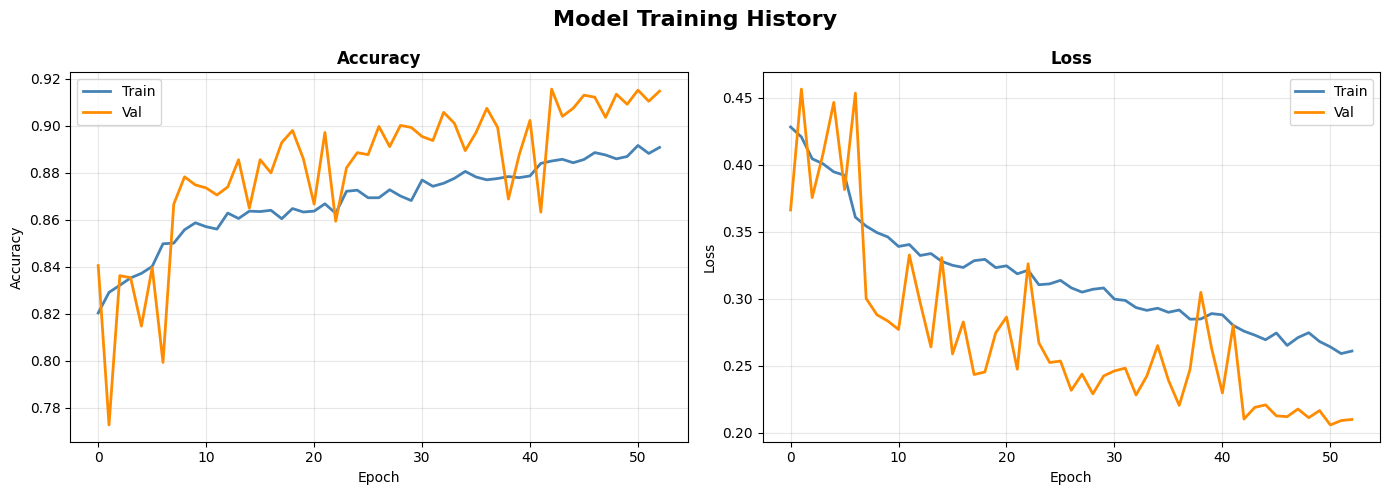

✅ Saved: training_history.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=16, fontweight='bold')

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='darkorange', linewidth=2)
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='steelblue',  linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='darkorange', linewidth=2)
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: training_history.png')

## 🎯 STEP 12 — Evaluate on Test Set

In [22]:
# Load best saved model weights
best_model = load_model('best_gesture_model.h5')   # ← .h5 instead of .keras

test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'🎯 Test Accuracy : {test_acc * 100:.2f}%')
print(f'📉 Test Loss     : {test_loss:.4f}')

y_pred        = best_model.predict(X_test, verbose=0)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = y_test

print('\n📋 Classification Report:')
print('=' * 60)
print(classification_report(
    y_true_labels, y_pred_labels,
    target_names=CLASSES
))

🎯 Test Accuracy : 90.57%
📉 Test Loss     : 0.2274

📋 Classification Report:
              precision    recall  f1-score   support

  Left Swipe       0.80      0.83      0.82       424
 Right Swipe       0.83      0.80      0.81       408
        Stop       0.92      0.98      0.95       557
 Thumbs Down       0.97      0.93      0.95       510
   Thumbs Up       0.98      0.95      0.96       433

    accuracy                           0.91      2332
   macro avg       0.90      0.90      0.90      2332
weighted avg       0.91      0.91      0.91      2332



## 🗺️ STEP 13 — Confusion Matrix

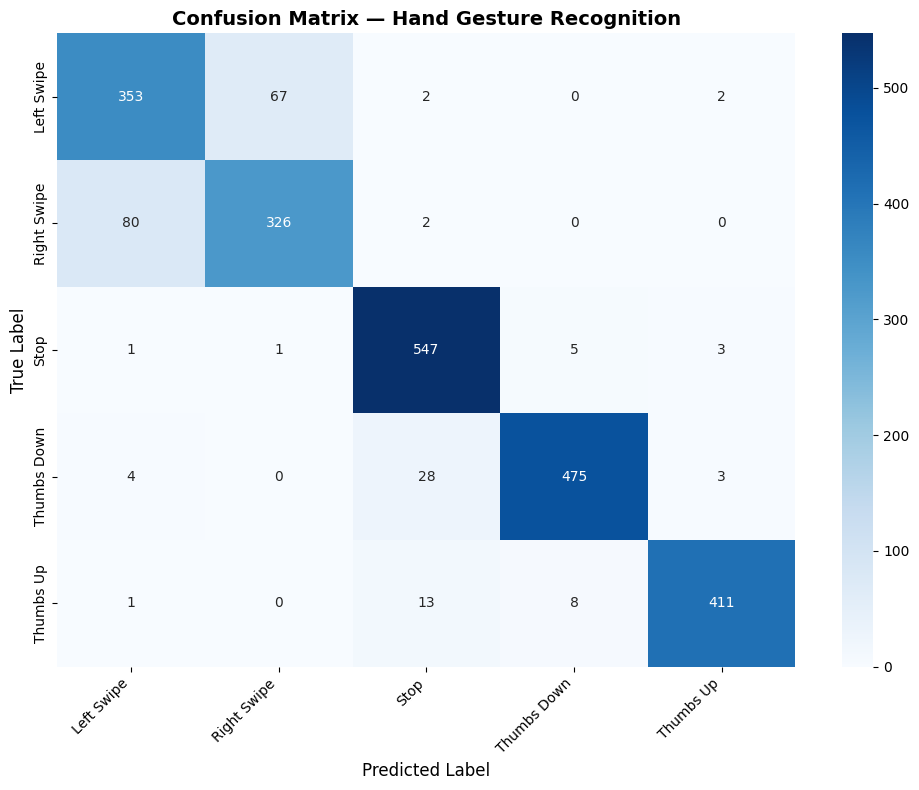

✅ Saved: confusion_matrix.png


In [23]:
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(max(10, NUM_CLASSES), max(8, NUM_CLASSES - 2)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES
)
plt.title('Confusion Matrix — Hand Gesture Recognition', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Saved: confusion_matrix.png')

## 💾 STEP 14 — Save Model & Class Info

In [24]:
# Save model
best_model.save('hand_gesture_model_v2.h5')

# Save class names
with open('gesture_classes.json', 'w') as f:
    json.dump({'classes': CLASSES}, f, indent=2)

print('✅ Model saved      : hand_gesture_model_v2.h5')
print('✅ Classes saved    : gesture_classes.json')
print(f'\n🏷️  Classes: {CLASSES}')

✅ Model saved      : hand_gesture_model_v2.h5
✅ Classes saved    : gesture_classes.json

🏷️  Classes: ['Left Swipe', 'Right Swipe', 'Stop', 'Thumbs Down', 'Thumbs Up']


## 🖼️ STEP 15 — Test on a Single Image File

In [27]:
def predict_from_image_file(image_path, model, classes):
    """
    Predict gesture from a saved image file.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f'❌ Cannot read: {image_path}')
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(
        static_image_mode=True, max_num_hands=1,
        min_detection_confidence=0.3
    ) as hands:
        results = hands.process(img_rgb)

        if not results.multi_hand_landmarks:
            print('❌ No hand detected in this image.')
            plt.figure(figsize=(5, 5))
            plt.imshow(img_rgb)
            plt.title('No hand detected', color='red', fontweight='bold')
            plt.axis('off')
            plt.show()
            return

        # Draw landmarks on image
        annotated = img_rgb.copy()
        for hand_lm in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                annotated, hand_lm,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style()
            )

        # Extract features
        features = []
        for lm in results.multi_hand_landmarks[0].landmark:
            features.extend([lm.x, lm.y, lm.z])
        features = np.array(features, dtype='float32').reshape(1, -1)

    # Predict
    preds = model.predict(features, verbose=0)
    pred_idx  = np.argmax(preds[0])
    confidence = preds[0][pred_idx] * 100
    pred_class = classes[pred_idx]

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(annotated)
    axes[1].set_title(
        f'Predicted: {pred_class}\nConfidence: {confidence:.1f}%',
        fontweight='bold', fontsize=13,
        color='green' if confidence > 70 else 'orange'
    )
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    print(f'\n🖐️  Predicted Gesture : {pred_class}')
    print(f'🎯 Confidence        : {confidence:.2f}%')
    print('\n📊 All class probabilities:')
    for i, cls in enumerate(classes):
        bar = '█' * int(preds[0][i] * 30)
        print(f'   {cls:25s}: {preds[0][i]*100:5.1f}%  {bar}')




## 🎥 STEP 16 — LIVE WEBCAM DEMO 🔴
**Real-time hand gesture recognition using your webcam.**

- ✋ Show your hand clearly to the camera
- 🟢 Green box = hand detected, prediction shown
- 🔴 Red text = no hand detected
- ⌨️ Press **`Q`** on the webcam window to quit

> ⚠️ **Run this as the LAST cell.** It opens a separate window.

In [ ]:
def run_webcam_demo(model, classes):
    """
    Real-time hand gesture recognition via webcam.
    Uses MediaPipe to extract landmarks each frame,
    then predicts using the trained MLP model.
    Press Q to quit.
    """
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print('❌ Cannot open webcam.')
        print('   → Check if camera is connected and not used by another app.')
        return

    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

    print('🎥 Webcam started!')
    print('   ✋ Show your hand gesture')
    print('   ⌨️  Press Q to quit\n')

    # Smoothing: keep last N predictions
    SMOOTH_N = 5
    pred_history = []

    # Colour palette for gestures
    palette = plt.cm.Set1(np.linspace(0, 1, len(classes)))
    colours = {
        cls: tuple(int(c * 255) for c in palette[i][:3][::-1])
        for i, cls in enumerate(classes)
    }

    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        min_detection_confidence=0.6,
        min_tracking_confidence=0.5
    ) as hands:

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.flip(frame, 1)          # mirror
            h, w  = frame.shape[:2]
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results   = hands.process(frame_rgb)

            # ── Overlay: semi-transparent dark header bar ──
            overlay = frame.copy()
            cv2.rectangle(overlay, (0, 0), (w, 90), (20, 20, 20), -1)
            cv2.addWeighted(overlay, 0.7, frame, 0.3, 0, frame)

            cv2.putText(frame, 'Hand Gesture Recognition',
                        (15, 30), cv2.FONT_HERSHEY_DUPLEX,
                        0.8, (255, 255, 255), 1)
            cv2.putText(frame, 'Press Q to quit',
                        (15, 60), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (180, 180, 180), 1)

            if results.multi_hand_landmarks:
                hand_lm = results.multi_hand_landmarks[0]

                # Draw skeleton on frame
                mp_drawing.draw_landmarks(
                    frame, hand_lm,
                    mp_hands.HAND_CONNECTIONS,
                    mp_drawing_styles.get_default_hand_landmarks_style(),
                    mp_drawing_styles.get_default_hand_connections_style()
                )

                # Extract features
                features = []
                for lm in hand_lm.landmark:
                    features.extend([lm.x, lm.y, lm.z])
                features = np.array(features, dtype='float32').reshape(1, -1)

                # Predict
                preds      = model.predict(features, verbose=0)
                pred_idx   = int(np.argmax(preds[0]))
                confidence = preds[0][pred_idx] * 100
                pred_class = classes[pred_idx]

                # Smooth predictions
                pred_history.append(pred_idx)
                if len(pred_history) > SMOOTH_N:
                    pred_history.pop(0)
                smooth_idx   = max(set(pred_history), key=pred_history.count)
                smooth_class = classes[smooth_idx]
                col = colours.get(smooth_class, (0, 255, 0))

                # Bounding box around hand
                xs = [int(lm.x * w) for lm in hand_lm.landmark]
                ys = [int(lm.y * h) for lm in hand_lm.landmark]
                x1, y1 = max(min(xs) - 20, 0), max(min(ys) - 20, 0)
                x2, y2 = min(max(xs) + 20, w), min(max(ys) + 20, h)
                cv2.rectangle(frame, (x1, y1), (x2, y2), col, 2)

                # Gesture label above bounding box
                label_text = f'{smooth_class}  {confidence:.0f}%'
                (tw, th), _ = cv2.getTextSize(
                    label_text, cv2.FONT_HERSHEY_DUPLEX, 0.9, 2
                )
                lx, ly = x1, max(y1 - 10, th + 5)
                cv2.rectangle(frame, (lx, ly - th - 8), (lx + tw + 10, ly + 4), col, -1)
                cv2.putText(frame, label_text,
                            (lx + 5, ly), cv2.FONT_HERSHEY_DUPLEX,
                            0.9, (255, 255, 255), 2)

                # Mini confidence bar at bottom
                bar_y = h - 20
                cv2.rectangle(frame, (10, bar_y), (10 + 300, bar_y + 12),
                              (60, 60, 60), -1)
                cv2.rectangle(frame, (10, bar_y),
                              (10 + int(confidence * 3), bar_y + 12), col, -1)
                cv2.putText(frame, f'Confidence: {confidence:.1f}%',
                            (320, bar_y + 11),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            else:
                pred_history.clear()
                cv2.putText(frame, 'No hand detected — show your hand!',
                            (w // 2 - 220, h // 2),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.85,
                            (0, 0, 255), 2)

            cv2.imshow('Hand Gesture Recognition | Press Q to quit', frame)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()
    print('\n✅ Webcam demo ended.')


# ▶️ Launch Live Demo
run_webcam_demo(best_model, CLASSES)

🎥 Webcam started!
   ✋ Show your hand gesture
   ⌨️  Press Q to quit



## 🔄 STEP 17 — Load Model Later (Skip Re-training)
Run this cell anytime to load the saved model and jump straight to webcam demo.

In [29]:
# Load saved model and classes
loaded_model = load_model('hand_gesture_model_v2.h5')

with open('gesture_classes.json', 'r') as f:
    loaded_classes = json.load(f)['classes']

print('✅ Model loaded!')
print(f'🏷️  Classes: {loaded_classes}')

# Uncomment to run webcam directly:
# run_webcam_demo(loaded_model, loaded_classes)

✅ Model loaded!
🏷️  Classes: ['Left Swipe', 'Right Swipe', 'Stop', 'Thumbs Down', 'Thumbs Up']


---
## ✅ Project Summary

| Component | Details |
|-----------|----------|
| **Feature Extraction** | MediaPipe — 21 hand landmarks × (x,y,z) = 63 features |
| **Model** | MLP — 512→256→128→64→N classes |
| **Regularisation** | BatchNorm + Dropout + EarlyStopping |
| **Augmentation** | Natural via landmark normalisation |
| **Webcam Demo** | Real-time with skeleton overlay + confidence bar |
| **Saved Files** | `hand_gesture_model_v2.keras`, `gesture_classes.json` |

---
*Hand Gesture Recognition System | ML Internship Task 04*